# A/B Testing Analysis: Control Campaign vs Test Campaign

This notebook performs an end-to-end A/B testing analysis on two marketing campaign datasets:

- `control_group.csv`
- `test_group.csv`

The goal is to compare both campaigns and understand which one performs better across traffic, engagement, conversion, and cost-efficiency metrics.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


In [ ]:
control = pd.read_csv("/content/control_group.csv", sep=";")
test = pd.read_csv("/content/test_group.csv", sep=";")

print("Control shape:", control.shape)
print("Test shape:", test.shape)


Control shape: (30, 10)
Test shape: (30, 10)


In [ ]:
control.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0000,56930.0000,7016.0000,2290.0000,2159.0000,1819.0000,618.0000
1,Control Campaign,2.08.2019,1757,121040.0000,102513.0000,8110.0000,2033.0000,1841.0000,1219.0000,511.0000
2,Control Campaign,3.08.2019,2343,131711.0000,110862.0000,6508.0000,1737.0000,1549.0000,1134.0000,372.0000
3,Control Campaign,4.08.2019,1940,72878.0000,61235.0000,3065.0000,1042.0000,982.0000,1183.0000,340.0000
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
test.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


### 4. Check Missing Values




In [ ]:
print("Missing values in Control group:")
display(control.isnull().sum())

print("\nMissing values in Test group:")
display(test.isnull().sum())


Missing values in Control group:


,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,1
Reach,1
# of Website Clicks,1
# of Searches,1
# of View Content,1
# of Add to Cart,1
# of Purchase,1



Missing values in Test group:


,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,0
Reach,0
# of Website Clicks,0
# of Searches,0
# of View Content,0
# of Add to Cart,0
# of Purchase,0


## 5. Clean the Data

Cleaning steps:

1. Standardize column names.
2. Convert the `Date` column to datetime.
3. Fill missing numeric values using interpolation.
4. Add a group label to each dataset.

Interpolation is useful here because this is daily campaign data. If one day has missing values, we estimate it based on surrounding days instead of dropping the row.


In [ ]:
def clean_campaign_data(df):
    df = df.copy()

    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace("# of ", "", regex=False)
        .str.replace(" [usd]", "", regex=False)
        .str.replace(" ", "_")
    )

    df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y")

    numeric_cols = df.select_dtypes(include="number").columns
    df[numeric_cols] = df[numeric_cols].interpolate().round(0)

    return df

control_clean = clean_campaign_data(control)
test_clean = clean_campaign_data(test)

control_clean["group"] = "Control"
test_clean["group"] = "Test"

df = pd.concat([control_clean, test_clean], ignore_index=True)

df.head()


,campaign_name,date,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0000,56930.0000,7016.0000,2290.0000,2159.0000,1819.0000,618.0000,Control
1,Control Campaign,2019-08-02,1757,121040.0000,102513.0000,8110.0000,2033.0000,1841.0000,1219.0000,511.0000,Control
2,Control Campaign,2019-08-03,2343,131711.0000,110862.0000,6508.0000,1737.0000,1549.0000,1134.0000,372.0000,Control
3,Control Campaign,2019-08-04,1940,72878.0000,61235.0000,3065.0000,1042.0000,982.0000,1183.0000,340.0000,Control
4,Control Campaign,2019-08-05,1835,90977.0000,74616.0000,3546.0000,1376.0000,1116.0000,984.0000,552.0000,Control


## 6. Create Derived Metrics

We create important marketing metrics:

- **CTR** = Website Clicks / Impressions
- **Click-to-Purchase Rate** = Purchases / Website Clicks
- **Cart-to-Purchase Rate** = Purchases / Add to Cart
- **CPC** = Spend / Website Clicks
- **CPA** = Spend / Purchases
- **CPM** = Spend / Impressions × 1000


In [ ]:
df["ctr"] = df["website_clicks"] / df["impressions"]
df["click_to_purchase_rate"] = df["purchase"] / df["website_clicks"]
df["cart_to_purchase_rate"] = df["purchase"] / df["add_to_cart"]
df["cpc"] = df["spend"] / df["website_clicks"]
df["cpa"] = df["spend"] / df["purchase"]
df["cpm"] = (df["spend"] / df["impressions"]) * 1000

df.head()


,campaign_name,date,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group,ctr,click_to_purchase_rate,cart_to_purchase_rate,cpc,cpa,cpm
0,Control Campaign,2019-08-01,2280,82702.0000,56930.0000,7016.0000,2290.0000,2159.0000,1819.0000,618.0000,Control,0.0848,0.0881,0.3397,0.3250,3.6893,27.5689
1,Control Campaign,2019-08-02,1757,121040.0000,102513.0000,8110.0000,2033.0000,1841.0000,1219.0000,511.0000,Control,0.0670,0.0630,0.4192,0.2166,3.4384,14.5159
2,Control Campaign,2019-08-03,2343,131711.0000,110862.0000,6508.0000,1737.0000,1549.0000,1134.0000,372.0000,Control,0.0494,0.0572,0.3280,0.3600,6.2984,17.7889
3,Control Campaign,2019-08-04,1940,72878.0000,61235.0000,3065.0000,1042.0000,982.0000,1183.0000,340.0000,Control,0.0421,0.1109,0.2874,0.6330,5.7059,26.6198
4,Control Campaign,2019-08-05,1835,90977.0000,74616.0000,3546.0000,1376.0000,1116.0000,984.0000,552.0000,Control,0.0390,0.1557,0.5610,0.5175,3.3243,20.1699


## 7. Overall Campaign Totals

This gives a high-level comparison of total performance for both campaigns.


In [ ]:
total_metrics = [
    "spend", "impressions", "reach", "website_clicks",
    "searches", "view_content", "add_to_cart", "purchase"
]

campaign_totals = df.groupby("group")[total_metrics].sum().T
campaign_totals["difference_test_minus_control"] = campaign_totals["Test"] - campaign_totals["Control"]
campaign_totals["lift_%"] = ((campaign_totals["Test"] / campaign_totals["Control"]) - 1) * 100

campaign_totals


group,Control,Test,difference_test_minus_control,lift_%
spend,68653.0000,76892.0000,8239.0000,12.0009
impressions,3268210.0000,2237544.0000,-1030666.0000,-31.5361
reach,2651119.0000,1604747.0000,-1046372.0000,-39.4691
website_clicks,157849.0000,180970.0000,23121.0000,14.6475
searches,65794.0000,72569.0000,6775.0000,10.2973
view_content,57486.0000,55740.0000,-1746.0000,-3.0373
add_to_cart,38684.0000,26446.0000,-12238.0000,-31.6358
purchase,15713.0000,15637.0000,-76.0000,-0.4837


## 8. Average Daily Performance

This compares the average daily performance of the two campaigns.


In [ ]:
daily_average = df.groupby("group").mean(numeric_only=True).T
daily_average["difference_test_minus_control"] = daily_average["Test"] - daily_average["Control"]
daily_average["lift_%"] = ((daily_average["Test"] / daily_average["Control"]) - 1) * 100

daily_average


group,Control,Test,difference_test_minus_control,lift_%
spend,2288.4333,2563.0667,274.6333,12.0009
impressions,108940.3333,74584.8000,-34355.5333,-31.5361
reach,88370.6333,53491.5667,-34879.0667,-39.4691
website_clicks,5261.6333,6032.3333,770.7000,14.6475
searches,2193.1333,2418.9667,225.8333,10.2973
view_content,1916.2000,1858.0000,-58.2000,-3.0373
add_to_cart,1289.4667,881.5333,-407.9333,-31.6358
purchase,523.7667,521.2333,-2.5333,-0.4837
ctr,0.0506,0.1024,0.0519,102.5791
click_to_purchase_rate,0.1161,0.0923,-0.0238,-20.5135


## 9. Funnel Visualization

This plot shows how users move through the campaign funnel.


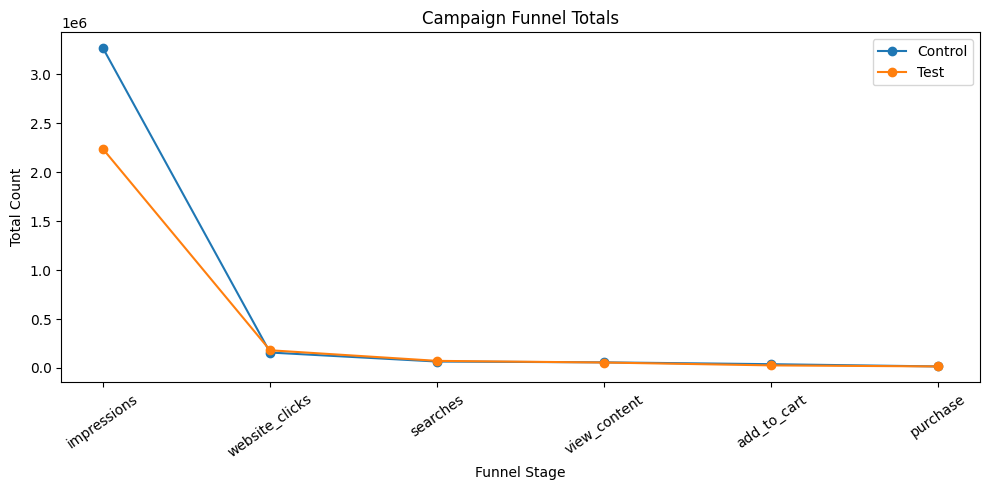

In [ ]:
funnel_metrics = [
    "impressions", "website_clicks", "searches",
    "view_content", "add_to_cart", "purchase"
]

funnel_totals = df.groupby("group")[funnel_metrics].sum().T

plt.figure(figsize=(10, 5))

for group in funnel_totals.columns:
    plt.plot(funnel_totals.index, funnel_totals[group], marker="o", label=group)

plt.title("Campaign Funnel Totals")
plt.xlabel("Funnel Stage")
plt.ylabel("Total Count")
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Conversion Rate Visualization

This plot compares the average daily conversion rates.


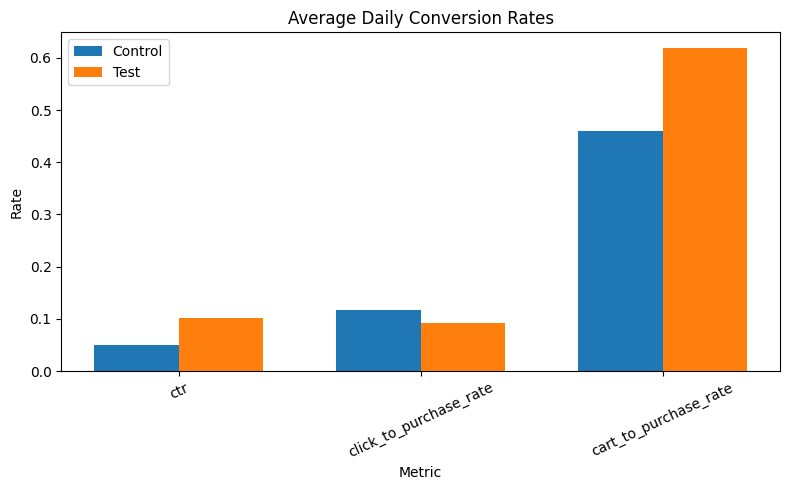

In [ ]:
rate_metrics = [
    "ctr", "click_to_purchase_rate", "cart_to_purchase_rate"
]

rate_means = df.groupby("group")[rate_metrics].mean().T

plt.figure(figsize=(8, 5))

x = np.arange(len(rate_means.index))
width = 0.35

plt.bar(x - width / 2, rate_means["Control"], width, label="Control")
plt.bar(x + width / 2, rate_means["Test"], width, label="Test")

plt.title("Average Daily Conversion Rates")
plt.xlabel("Metric")
plt.ylabel("Rate")
plt.xticks(x, rate_means.index, rotation=25)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Purchases Over Time

This helps us see whether one campaign consistently generated more purchases over time.


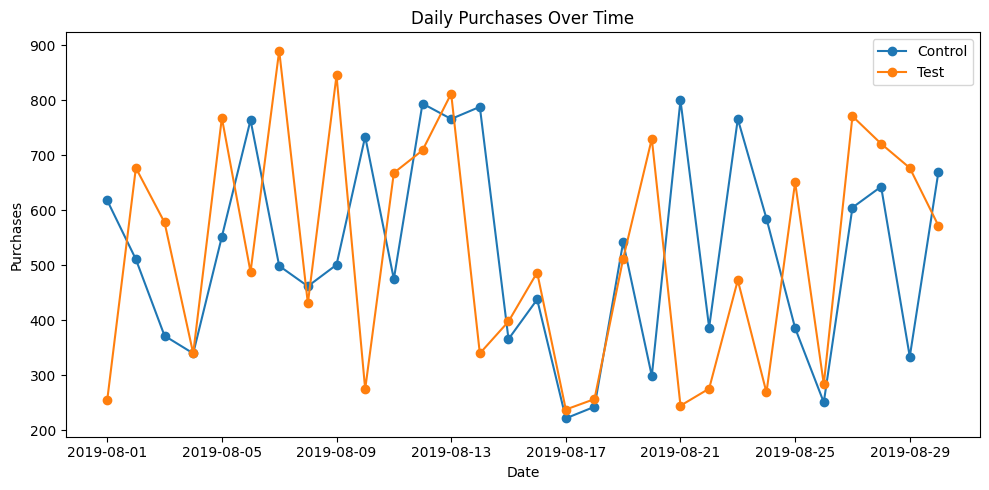

In [ ]:
daily_purchases = df.pivot(index="date", columns="group", values="purchase")

plt.figure(figsize=(10, 5))

plt.plot(daily_purchases.index, daily_purchases["Control"], marker="o", label="Control")
plt.plot(daily_purchases.index, daily_purchases["Test"], marker="o", label="Test")

plt.title("Daily Purchases Over Time")
plt.xlabel("Date")
plt.ylabel("Purchases")
plt.legend()
plt.tight_layout()
plt.show()


## 12. CPA Over Time

CPA means Cost Per Acquisition. Lower CPA is better.


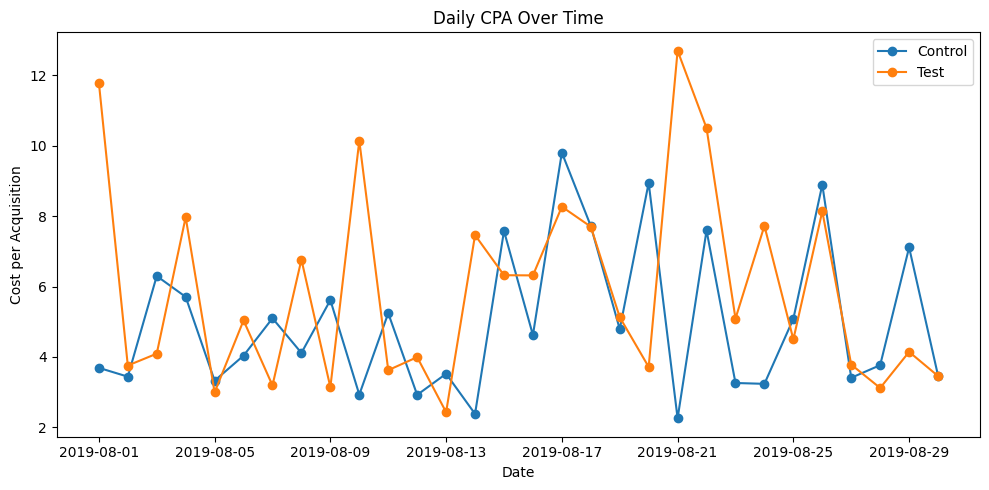

In [ ]:
daily_cpa = df.pivot(index="date", columns="group", values="cpa")

plt.figure(figsize=(10, 5))

plt.plot(daily_cpa.index, daily_cpa["Control"], marker="o", label="Control")
plt.plot(daily_cpa.index, daily_cpa["Test"], marker="o", label="Test")

plt.title("Daily CPA Over Time")
plt.xlabel("Date")
plt.ylabel("Cost per Acquisition")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Statistical Testing: Welch's T-Test

We use Welch's t-test because it does not assume equal variance between the two groups.

Hypotheses:

- **Null hypothesis:** There is no difference between Control and Test.
- **Alternative hypothesis:** There is a difference between Control and Test.

If `p_value < 0.05`, the result is statistically significant.


In [ ]:
metrics = [
    "spend", "impressions", "reach", "website_clicks", "searches",
    "view_content", "add_to_cart", "purchase",
    "ctr", "click_to_purchase_rate", "cart_to_purchase_rate",
    "cpc", "cpa", "cpm"
]

results = []

for metric in metrics:
    control_values = df[df["group"] == "Control"][metric]
    test_values = df[df["group"] == "Test"][metric]

    t_stat, p_value = stats.ttest_ind(
        test_values,
        control_values,
        equal_var=False,
        nan_policy="omit"
    )

    control_mean = control_values.mean()
    test_mean = test_values.mean()

    results.append({
        "metric": metric,
        "control_mean": control_mean,
        "test_mean": test_mean,
        "absolute_difference": test_mean - control_mean,
        "lift_%": ((test_mean / control_mean) - 1) * 100,
        "p_value": p_value,
        "significant_0.05": p_value < 0.05
    })

ab_results = pd.DataFrame(results).sort_values("p_value")
ab_results


,metric,control_mean,test_mean,absolute_difference,lift_%,p_value,significant_0.05
2,reach,88370.6333,53491.5667,-34879.0667,-39.4691,0.0000,True
1,impressions,108940.3333,74584.8000,-34355.5333,-31.5361,0.0000,True
13,cpm,21.6642,42.6810,21.0169,97.0120,0.0000,True
6,add_to_cart,1289.4667,881.5333,-407.9333,-31.6358,0.0001,True
8,ctr,0.0506,0.1024,0.0519,102.5791,0.0003,True
0,spend,2288.4333,2563.0667,274.6333,12.0009,0.0043,True
10,cart_to_purchase_rate,0.4606,0.6179,0.1573,34.1505,0.0081,True
3,website_clicks,5261.6333,6032.3333,770.7000,14.6475,0.0903,False
9,click_to_purchase_rate,0.1161,0.0923,-0.0238,-20.5135,0.1132,False
12,cpa,4.9947,5.8996,0.9049,18.1161,0.1629,False


## 14. Proportion Z-Test for Rate Metrics

For aggregated conversion rates, we use a two-proportion z-test.

This is useful for metrics such as:

- CTR
- Click-to-purchase rate
- Cart-to-purchase rate


In [ ]:
prop_tests = []

for label, numerator, denominator in [
    ("CTR", "website_clicks", "impressions"),
    ("Click to Purchase Rate", "purchase", "website_clicks"),
    ("Cart to Purchase Rate", "purchase", "add_to_cart")
]:
    control_count = df[df["group"] == "Control"][numerator].sum()
    test_count = df[df["group"] == "Test"][numerator].sum()

    control_den = df[df["group"] == "Control"][denominator].sum()
    test_den = df[df["group"] == "Test"][denominator].sum()

    z_stat, p_value = proportions_ztest(
        count=np.array([control_count, test_count]),
        nobs=np.array([control_den, test_den])
    )

    control_rate = control_count / control_den
    test_rate = test_count / test_den

    prop_tests.append({
        "metric": label,
        "control_rate": control_rate,
        "test_rate": test_rate,
        "lift_%": ((test_rate / control_rate) - 1) * 100,
        "p_value": p_value,
        "significant_0.05": p_value < 0.05
    })

prop_results = pd.DataFrame(prop_tests)
prop_results


,metric,control_rate,test_rate,lift_%,p_value,significant_0.05
0,CTR,0.0483,0.0809,67.4569,0.0000,True
1,Click to Purchase Rate,0.0995,0.0864,-13.1980,0.0000,True
2,Cart to Purchase Rate,0.4062,0.5913,45.5679,0.0000,True


## 15. Key Insights

From the analysis:

1. The Test Campaign generated fewer impressions and lower reach than the Control Campaign.
2. The Test Campaign generated more website clicks.
3. The Test Campaign had a much higher CTR.
4. The Test Campaign did not generate more purchases.
5. The Control Campaign had better purchase efficiency.
6. The Test Campaign had a higher CPA, meaning it was more expensive per purchase.
7. The Test Campaign attracted more users, but those users were less likely to purchase.


## 16. Conclusion

The Test Campaign is better for traffic generation because it achieved a much higher CTR and more website clicks.

However, the Test Campaign should not be declared the overall winner if the main business goal is purchases or cost efficiency.

The Control Campaign is safer for purchase-focused performance because it achieved almost the same number of purchases with lower cost pressure.

### Final Decision

- If the goal is **awareness or traffic**, choose the **Test Campaign**.
- If the goal is **sales, purchases, and CPA efficiency**, choose the **Control Campaign**.


## 17. Business Recommendations

Recommended next steps:

1. Keep the Control Campaign active for purchase-focused traffic.
2. Use the Test Campaign for awareness or traffic campaigns.
3. Improve the Test Campaign landing page and offer alignment.
4. Investigate why Test Campaign users click more but purchase less.
5. Run another A/B test with a clearly defined primary KPI such as purchase rate, CPA, or revenue.
6. If more data is available, segment results by audience, device, location, and traffic source.
